# 3.1 New Embodiment Finetuning Tutorial (Python API)

This provides a step-by-step guide on how to finetune GR00T-N1.5 with our python API, the G1 Block Stacking Dataset is used as an example.

This is a more detailed version of the [3_0_new_embodiment_finetuning.md](3_0_new_embodiment_finetuning.md) tutorial, which explains in-depth the details of configuring the dataset, transforms, and finetuning.


---

## Step 1: Dataset

Loading any dataset for finetuning can be done in 2 steps:
- 1.1: Defining the modality configs and transforms for the dataset
- 1.2: Loading the dataset using the `LeRobotSingleDataset` class

### Step: 1.0 Download the dataset

- Download the dataset from: https://huggingface.co/datasets/unitreerobotics/G1_BlockStacking_Dataset
- copy over the `examples/unitree_g1_blocks__modality.json` to the dataset `<DATASET_PATH>/meta/modality.json`
  - This provides additional information about the state and action modalities to make it "GR00T-compatible"
  - `cp examples/unitree_g1_blocks__modality.json datasets/G1_BlockStacking_Dataset/meta/modality.json`


**Understanding the Modality Configs**

This file provides detailed metadata about state and action modalities, enabling:

- **Separate Data Storage and Interpretation:**
  - **State and Action:** Stored as concatenated float32 arrays. The `modality.json` file supplies the metadata necessary to interpret these arrays as distinct, fine-grained fields with additional training information.
  - **Video:** Stored as separate files, with the configuration file allowing them to be renamed to a standardized format.
  - **Annotations:** Keeps track of all annotation fields. If there are no annotations, do not include the `annotation` field in the configuration file.
- **Fine-Grained Splitting:** Divides the state and action arrays into more semantically meaningful fields.
- **Clear Mapping:** Explicit mapping of data dimensions.
- **Sophisticated Data Transformations:** Supports field-specific normalization and rotation transformations during training.

#### Schema

```json
{
    "state": {
        "<state_name>": {
            "start": <int>,         // Starting index in the state array
            "end": <int>,           // Ending index in the state array
        }
    },
    "action": {
        "<action_name>": {
            "start": <int>,         // Starting index in the action array
            "end": <int>,           // Ending index in the action array
        }
    },
    "video": {
        "<video_name>": {}  // Empty dictionary to maintain consistency with other modalities
    },
    "annotation": {
        "<annotation_name>": {}  // Empty dictionary to maintain consistency with other modalities
    }
}
```

Example is shown in `getting_started/examples/unitree_g1_blocks__modality.json`. This file is located in the `meta` folder of the lerobot dataset.


Generate the Stats (`meta/metadata.json`) by running the following command:
```bash
python scripts/load_dataset.py --data_path /datasets/G1_BlockStacking_Dataset/ --embodiment_tag new_embodiment
```

In [1]:
from gr00t.data.schema import EmbodimentTag

In [2]:
dataset_path = "../demo_data/g1"  # change this to your dataset path
embodiment_tag = EmbodimentTag.NEW_EMBODIMENT

### Step: 1.1 Modality configs and transforms

Modality configs let you select which specific data streams to use for each input type (video, state, action, language, etc.) during finetuning, giving you precise control over which parts of your dataset are utilized.

In [3]:
from gr00t.data.dataset import ModalityConfig


# select the modality keys you want to use for finetuning
video_modality = ModalityConfig(
    delta_indices=[0],
    modality_keys=["video.rs_view"],
)

state_modality = ModalityConfig(
    delta_indices=[0],
    modality_keys=["state.left_arm", "state.right_arm", "state.left_hand", "state.right_hand"],
)

action_modality = ModalityConfig(
    delta_indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    modality_keys=["action.left_arm", "action.right_arm", "action.left_hand", "action.right_hand"],
)

language_modality = ModalityConfig(
    delta_indices=[0],
    modality_keys=["annotation.human.task_description"],
)

modality_configs = {
    "video": video_modality,
    "state": state_modality,
    "action": action_modality,
    "language": language_modality,
}

/home/ergocub/miniforge3/envs/conda-gr00t/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from gr00t.data.transform.base import ComposedModalityTransform
from gr00t.data.transform import VideoToTensor, VideoCrop, VideoResize, VideoColorJitter, VideoToNumpy
from gr00t.data.transform.state_action import StateActionToTensor, StateActionTransform
from gr00t.data.transform.concat import ConcatTransform
from gr00t.model.transforms import GR00TTransform


# select the transforms you want to apply to the data
to_apply_transforms = ComposedModalityTransform(
    transforms=[
        # video transforms
        VideoToTensor(apply_to=video_modality.modality_keys, backend="torchvision"),
        VideoCrop(apply_to=video_modality.modality_keys, scale=0.95, backend="torchvision"),
        VideoResize(apply_to=video_modality.modality_keys, height=224, width=224, interpolation="linear", backend="torchvision" ),
        VideoColorJitter(apply_to=video_modality.modality_keys, brightness=0.3, contrast=0.4, saturation=0.5, hue=0.08, backend="torchvision"),
        VideoToNumpy(apply_to=video_modality.modality_keys),

        # state transforms
        StateActionToTensor(apply_to=state_modality.modality_keys),
        StateActionTransform(apply_to=state_modality.modality_keys, normalization_modes={
            "state.left_arm": "min_max",
            "state.right_arm": "min_max",
            "state.left_hand": "min_max",
            "state.right_hand": "min_max",
        }),

        # action transforms
        StateActionToTensor(apply_to=action_modality.modality_keys),
        StateActionTransform(apply_to=action_modality.modality_keys, normalization_modes={
            "action.right_arm": "min_max",
            "action.left_arm": "min_max",
            "action.right_hand": "min_max",
            "action.left_hand": "min_max",
        }),

        # ConcatTransform
        ConcatTransform(
            video_concat_order=video_modality.modality_keys,
            state_concat_order=state_modality.modality_keys,
            action_concat_order=action_modality.modality_keys,
        ),
        # model-specific transform
        GR00TTransform(
            state_horizon=len(state_modality.delta_indices),
            action_horizon=len(action_modality.delta_indices),
            max_state_dim=64,
            max_action_dim=32,
        ),
    ]
)


2025-07-01 14:34:47.756599: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-01 14:34:47.763772: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751373287.772677  306778 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751373287.776328  306778 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-01 14:34:47.786023: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

### Step 1.2 Load the dataset

First we will visualize the dataset and then load it using the `LeRobotSingleDataset` class. (without transforms)

In [5]:
from gr00t.data.dataset import LeRobotSingleDataset

train_dataset = LeRobotSingleDataset(
    dataset_path=dataset_path,
    modality_configs=modality_configs,
    embodiment_tag=embodiment_tag,
    video_backend="torchvision_av",
)


modality = 'state'
modality = 'action'
self.dataset_name = 'g1'
self.all_steps = [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 28), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0, 36), (0, 37), (0, 38), (0, 39), (0, 40), (0, 41), (0, 42), (0, 43), (0, 44), (0, 45), (0, 46), (0, 47), (0, 48), (0, 49), (0, 50), (0, 51), (0, 52), (0, 53), (0, 54), (0, 55), (0, 56), (0, 57), (0, 58), (0, 59), (0, 60), (0, 61), (0, 62), (0, 63), (0, 64), (0, 65), (0, 66), (0, 67), (0, 68), (0, 69), (0, 70), (0, 71), (0, 72), (0, 73), (0, 74), (0, 75), (0, 76), (0, 77), (0, 78), (0, 79), (0, 80), (0, 81), (0, 82), (0, 83), (0, 84), (0, 85), (0, 86), (0, 87), (0, 88), (0, 89), (0, 90), (0, 91), (0, 92), (0, 93), (0, 94), (0, 95), (0, 96), (0, 97), (0, 98), (0, 99), (0, 100), (0, 101), (0, 102)

Using original key task_index for annotation human.task_description
                                     observation.state  \
0    [-0.7028946876525879, 0.08080673217773438, 0.0...   
1    [-0.702880859375, 0.08080673217773438, 0.05679...   
2    [-0.7028946876525879, 0.08081507682800293, 0.0...   
3    [-0.7028946876525879, 0.08080673217773438, 0.0...   
4    [-0.7028946876525879, 0.08082365989685059, 0.0...   
..                                                 ...   
106  [-0.7031621932983398, 0.0828859806060791, 0.04...   
107  [-0.7033228874206543, 0.0828859806060791, 0.04...   
108  [-0.7036442756652832, 0.08266448974609375, 0.0...   
109  [-0.7037115097045898, 0.0826730728149414, 0.04...   
110  [-0.70343017578125, 0.08272409439086914, 0.042...   

                                                action  \
0    [-0.5327178299427032, -0.0441613495349884, 0.1...   
1    [-0.5345414042472839, -0.04450938105583191, 0....   
2    [-0.5364068210124969, -0.04345101863145828, 0....   
3  

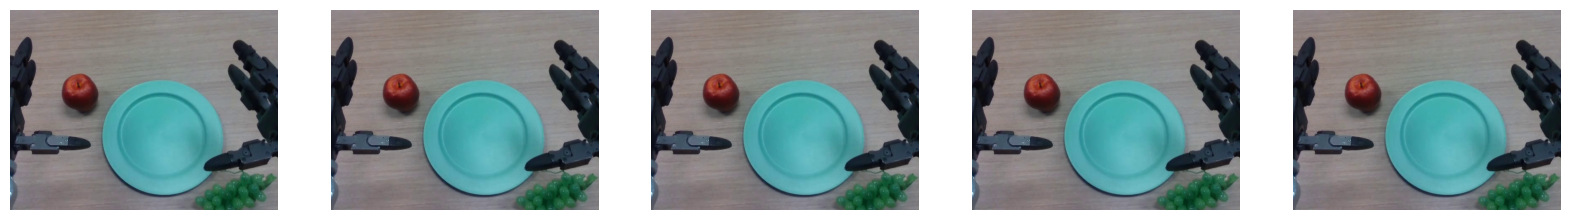

In [6]:
# use matplotlib to visualize the images
import matplotlib.pyplot as plt
import numpy as np

print(train_dataset[0].keys())

images = []
for i in range(5):
    image = train_dataset[i]["video.rs_view"][0]
    # image is in HWC format, convert it to CHW format
    image = image.transpose(2, 0, 1)
    images.append(image)   

fig, axs = plt.subplots(1, 5, figsize=(20, 5))
for i, image in enumerate(images):
    axs[i].imshow(np.transpose(image, (1, 2, 0)))
    axs[i].axis("off")
plt.show()

Now, we will initiate a dataset with our modality configs and transforms.

In [7]:
train_dataset = LeRobotSingleDataset(
    dataset_path=dataset_path,
    modality_configs=modality_configs,
    embodiment_tag=embodiment_tag,
    video_backend="torchvision_av",
    transforms=to_apply_transforms,
)

modality = 'state'
modality = 'action'
self.dataset_name = 'g1'
self.all_steps = [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 27), (0, 28), (0, 29), (0, 30), (0, 31), (0, 32), (0, 33), (0, 34), (0, 35), (0, 36), (0, 37), (0, 38), (0, 39), (0, 40), (0, 41), (0, 42), (0, 43), (0, 44), (0, 45), (0, 46), (0, 47), (0, 48), (0, 49), (0, 50), (0, 51), (0, 52), (0, 53), (0, 54), (0, 55), (0, 56), (0, 57), (0, 58), (0, 59), (0, 60), (0, 61), (0, 62), (0, 63), (0, 64), (0, 65), (0, 66), (0, 67), (0, 68), (0, 69), (0, 70), (0, 71), (0, 72), (0, 73), (0, 74), (0, 75), (0, 76), (0, 77), (0, 78), (0, 79), (0, 80), (0, 81), (0, 82), (0, 83), (0, 84), (0, 85), (0, 86), (0, 87), (0, 88), (0, 89), (0, 90), (0, 91), (0, 92), (0, 93), (0, 94), (0, 95), (0, 96), (0, 97), (0, 98), (0, 99), (0, 100), (0, 101), (0, 102)

**Extra Notes**:
 - We use a cached dataloader to accelerate training speed. The cached dataloader loads all data into memory, which significantly improves training performance. However, if your dataset is large or you're experiencing out-of-memory (OOM) errors, you can switch to the standard lerobot dataloader (`gr00t.data.dataset.LeRobotSingleDataset`). It uses the same API as the cached dataloader, so you can switch back and forth without any changes to your code.
 - we use torchvision_av as the video backend, the video encoding is in av instead of standard h264


### Step 2: Load the model

The training process is done in 3 steps:
- 2.1: Load the base model from HuggingFace or a local path
- 2.2: Prepare training args
- 2.3: Run the training loop

#### Step 2.1 Load the base model

We'll use the `from_pretrained_for_tuning` method to load the model. This method allows us to specify which parts of the model to tune.

In [8]:
import os
import torch
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
from gr00t.model.gr00t_n1 import GR00T_N1_5

BASE_MODEL_PATH = "nvidia/GR00T-N1.5-3B"
TUNE_LLM = False            # Whether to tune the LLM
TUNE_VISUAL = False          # Whether to tune the visual encoder
TUNE_PROJECTOR = True       # Whether to tune the projector
TUNE_DIFFUSION_MODEL = False # Whether to tune the diffusion model

model = GR00T_N1_5.from_pretrained(
    pretrained_model_name_or_path=BASE_MODEL_PATH,
    tune_llm=TUNE_LLM,  # backbone's LLM
    tune_visual=TUNE_VISUAL,  # backbone's vision tower
    tune_projector=TUNE_PROJECTOR,  # action head's projector
    tune_diffusion_model=TUNE_DIFFUSION_MODEL,  # action head's DiT
)

# Set the model's compute_dtype to bfloat16
model.compute_dtype = "bfloat16"
model.config.compute_dtype = "bfloat16"
model.to(device)

Loading pretrained dual brain from nvidia/GR00T-N1.5-3B
Tune backbone vision tower: False
Tune backbone LLM: False
Tune action head projector: True
Tune action head DiT: False


Fetching 14 files: 100%|██████████| 14/14 [00:00<00:00, 279620.27it/s]


Tune backbone llm: False
Tune backbone visual: True
Total number of DiT parameters:  550386688
Total number of SelfAttentionTransformer parameters:  201433088
Tune action head projector: True
Tune action head diffusion model: True


Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 34.39it/s]

pretrained model action_horizon 16
pretrained model action_dim 32
Tune backbone llm: False
Tune backbone visual: False
Tune action head projector: True
Tune action head diffusion model: False
kwargs = {}
pretrained model action_horizon 16
pretrained model action_dim 32
Tune Projector True


GR00T_N1_5(
  (backbone): EagleBackbone(
    (eagle_model): Eagle2_5_VLForConditionalGeneration(
      (vision_model): SiglipVisionModel(
        (vision_model): SiglipVisionTransformer(
          (embeddings): SiglipVisionEmbeddings(
            (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
            (position_embedding): Embedding(256, 1152)
          )
          (encoder): SiglipEncoder(
            (layers): ModuleList(
              (0-26): 27 x SiglipEncoderLayer(
                (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                (self_attn): SiglipAttention(
                  (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
                  (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
              

#### Step 2.2 Prepare training args

We use huggingface `TrainingArguments` to configure the training process. Here are the main parameters:

In [10]:
from transformers import TrainingArguments

output_dir = "output/model/path"    # CHANGE THIS ACCORDING TO YOUR LOCAL PATH
per_device_train_batch_size = 1     # CHANGE THIS ACCORDING TO YOUR GPU MEMORY
max_steps = 10                      # CHANGE THIS ACCORDING TO YOUR NEEDS
report_to = "wandb"
dataloader_num_workers = 8

training_args = TrainingArguments(
    output_dir=output_dir,
    run_name=None,
    remove_unused_columns=False,
    deepspeed="",
    gradient_checkpointing=False,
    bf16=True,
    tf32=True,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=1,
    dataloader_num_workers=dataloader_num_workers,
    dataloader_pin_memory=False,
    dataloader_persistent_workers=True,
    optim="adamw_torch",
    adam_beta1=0.95,
    adam_beta2=0.999,
    adam_epsilon=1e-8,
    learning_rate=1e-4,
    weight_decay=1e-5,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    logging_steps=10.0,
    num_train_epochs=300,
    max_steps=max_steps,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=8,
    report_to=report_to,
    seed=42,
    do_eval=False,
    ddp_find_unused_parameters=False,
    ddp_bucket_cap_mb=100,
    torch_compile_mode=None,
)


#### Step 2.3 Initialize the training runner and run the training loop

In [11]:
from gr00t.experiment.runner import TrainRunner

experiment = TrainRunner(
    train_dataset=train_dataset,
    model=model,
    training_args=training_args,
)

experiment.train()

Run name: output/model/path
GPU memory before DualBrainTrainer: 7.076502799987793 GB
GPU memory after: 7.076502799987793 GB
train dataloader length: 231
train dataset length: 231
GPU memory before training: 7.076502799987793 GB


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


TensorBoard logs will be saved to: output/model/path/runs


wandb: Currently logged in as: cacp3009 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using original key task_index for annotation human.task_description
Using original key task_index for annotation human.task_description
Using original key task_index for annotation human.task_description
Using original key task_index for annotation human.task_description
Using original key task_index for annotation human.task_descriptionUsing original key task_index for annotation human.task_description

                                     observation.state  \
0    [-0.7028946876525879, 0.08080673217773438, 0.0...   
1    [-0.702880859375, 0.08080673217773438, 0.05679...   
2    [-0.7028946876525879, 0.08081507682800293, 0.0...   
3    [-0.7028946876525879, 0.08080673217773438, 0.0...   
4    [-0.7028946876525879, 0.08082365989685059, 0.0...   
..                                                 ...   
106  [-0.7031621932983398, 0.0828859806060791, 0.04...   
107  [-0.7033228874206543, 0.0828859806060791, 0.04...   
108  [-0.7036442756652832, 0.08266448974609375, 0.0...   
109  [-0.703

/home/ergocub/repos/Isaac-GR00T/gr00t/model/action_head/cross_attention_dit.py:281: FutureWarning: Accessing config attribute `interleave_self_attention` directly via 'DiT' object attribute is deprecated. Please access 'interleave_self_attention' over 'DiT's config object instead, e.g. 'unet.config.interleave_self_attention'.
  if idx % 2 == 1 and self.interleave_self_attention:
Could not estimate the number of tokens of the input, floating-point operations will not be computed


Step,Training Loss
10,1.143100


Using original key task_index for annotation human.task_description
                                     observation.state  \
0    [-0.7037782669067383, 0.08118176460266113, 0.0...   
1    [-0.7038049697875977, 0.08119010925292969, 0.0...   
2    [-0.7036442756652832, 0.08118176460266113, 0.0...   
3    [-0.7035374641418457, 0.081207275390625, 0.046...   
4    [-0.7036442756652832, 0.081207275390625, 0.046...   
..                                                 ...   
115  [-0.702519416809082, 0.08203387260437012, 0.04...   
116  [-0.7025866508483887, 0.0820167064666748, 0.04...   
117  [-0.7025866508483887, 0.08204245567321777, 0.0...   
118  [-0.7025866508483887, 0.08206796646118164, 0.0...   
119  [-0.702613353729248, 0.08204245567321777, 0.04...   

                                                action  \
0    [-0.5462984800338745, -0.058052025735378265, 0...   
1    [-0.5482031464576721, -0.05809963494539261, 0....   
2    [-0.54418665766716, -0.056030333042144775, 0.1...   
3  

We can see the 1k offline validation results vs 10k offline validation results:

**Finetuning Results on Unitree G1 Block Stacking Dataset:**

| 1k Steps | 10k Steps |
| --- | --- |
| ![1k](../media/g1_ft_1k.png) | ![10k](../media/g1_ft_10k.png) |
| MSE: 0.0181 | MSE: 0.0022 |